In [1]:
"""
   Copyright (C) Sergei Vostrikov (Sergio5714), 2026
   
   Licensed under the Apache License, Version 2.0 (the "License");
   you may not use this file except in compliance with the License.
   You may obtain a copy of the License at
       http://www.apache.org/licenses/LICENSE-2.0
   Unless required by applicable law or agreed to in writing, software
   distributed under the License is distributed on an "AS IS" BASIS,
   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
   See the License for the specific language governing permissions and
   limitations under the License.

   SPDX-License-Identifier: Apache-2.0
"""

'\n   Copyright (C) Sergei Vostrikov (Sergio5714), 2026\n   \n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n       http://www.apache.org/licenses/LICENSE-2.0\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n\n   SPDX-License-Identifier: Apache-2.0\n'

# WULPUS Pro Example

Run this from the browser Jupyter server started with the `wulpus_pro_env` environment.

In [2]:
%matplotlib widget

from dataclasses import dataclass

from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as ss

from wulpus.wifi_link import WulpusProWiFiLink
from wulpus.usb_cdc_link import WulpusProUsbCdcLink
from wulpus.ble_dongle import WulpusBleDongle
from wulpus.gui import WulpusGuiSingleCh
from wulpus.rx_tx_conf_pro import WulpusProRxTxConfigGen
from wulpus.uss_conf_pro import WulpusProUssConfig
from wulpus.uss_conf_gui_pro import WulpusProUssConfigGUI
from wulpus.device_config_gui import WulpusProDeviceConfigGUI


## ESP32 Device Configuration

Connect over USB CDC to load and replace persistent device settings or set/clear write-only Wi-Fi credentials. Saved changes take effect after reboot. Stored SSIDs and passwords cannot be read back.

In [3]:
device_config_gui = WulpusProDeviceConfigGUI()
display(device_config_gui)


WulpusProDeviceConfigGUI(children=(HBox(children=(Button(description='Refresh', style=ButtonStyle()), Button(d…

## 1. Configure TX/RX Channels

Create the channel masks before launching the GUI. This default configuration transmits and receives on all 16 WULPUS PRO channels. Add more configurations with additional `add_config()` calls if required.

In [4]:
tx_rx = WulpusProRxTxConfigGen()
tx_rx.add_config(
    tx_channels=list(range(16)),
    rx_channels=list(range(16)),
)

print(f"TX configurations: {tx_rx.get_tx_configs()}")
print(f"RX configurations: {tx_rx.get_rx_configs()}")


TX configurations: [65535]
RX configurations: [65535]


## 2. Configure the Ultrasound Acquisition

Create the complete acquisition configuration from the TX/RX masks and the desired timing, excitation, sampling, and acquisition parameters. Edit these values before constructing the GUI.

In [5]:
uss_conf = WulpusProUssConfig(
    num_acqs=2000,
    trans_freq=2_250_000,
    pulse_freq=2_250_000,
    num_pulses=2,
    num_samples=400,
    num_txrx_configs=tx_rx.tx_rx_len,
    tx_configs=tx_rx.get_tx_configs(),
    rx_configs=tx_rx.get_rx_configs(),
)

print(f"Configuration package: {len(uss_conf.get_conf_package())} bytes")

uss_conf_gui = WulpusProUssConfigGUI(uss_conf)
display(uss_conf_gui)


Configuration package: 105 bytes


WulpusProUssConfigGUI(children=(HBox(children=(VBox(children=(HTML(value='<b>Measurement settings</b>'), Bound…

Adjust the settings above, then run the next cell to apply them before launching the acquisition GUI. The TX/RX masks remain those configured in section 1.

In [6]:
uss_conf = WulpusProUssConfig(
    num_acqs=uss_conf_gui.num_acqs,
    dcdc_turnon=uss_conf_gui.dcdc_turnon,
    meas_period=uss_conf_gui.meas_period,
    trans_freq=uss_conf_gui.trans_freq,
    pulse_freq=uss_conf_gui.pulse_freq,
    num_pulses=uss_conf_gui.num_pulses,
    sampling_freq=uss_conf_gui.sampling_freq,
    num_samples=uss_conf_gui.num_samples,
    rx_gain=uss_conf_gui.rx_gain,
    num_txrx_configs=tx_rx.tx_rx_len,
    tx_configs=tx_rx.get_tx_configs(),
    rx_configs=tx_rx.get_rx_configs(),
    start_hvmuxrx=uss_conf_gui.start_hvmuxrx,
    start_ppg=uss_conf_gui.start_ppg,
    turnon_adc=uss_conf_gui.turnon_adc,
    start_pgainbias=uss_conf_gui.start_pgainbias,
    start_adcsampl=uss_conf_gui.start_adcsampl,
    restart_capt=uss_conf_gui.restart_capt,
    capt_timeout=uss_conf_gui.capt_timeout,
    vga_rc_prech_cyc=uss_conf_gui.vga_rc_prech_cyc,
    vga_slope_code=uss_conf_gui.vga_slope_code,
    enable_env_det=uss_conf_gui.enable_env_det,
)

print(f"Applied configuration package: {len(uss_conf.get_conf_package())} bytes")


Applied configuration package: 105 bytes


## 3. Launch the GUI

Select WiFi or BLE in the GUI, scan for a device, open it, and start the measurement.

WulpusGuiSingleCh(children=(VBox(children=(HBox(children=(VBox(children=(Checkbox(value=True, description='Sho…

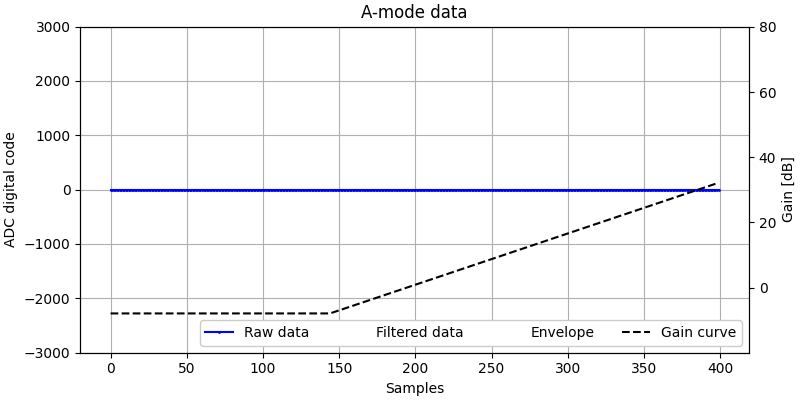

In [8]:
communication_links = {
    "USB CDC": WulpusProUsbCdcLink(),
    "Wi-Fi": WulpusProWiFiLink(
        service_name="wulpus_pro", service_type="tcp", port=2121
    ),
    "BLE": WulpusBleDongle(),
}

gui = WulpusGuiSingleCh(communication_links, uss_conf, max_vis_fps=20)
display(gui)


## 4. Run .npz viewer

And inspect the acquisitions you saved (if you saved any)

In [9]:
from wulpus.npz_viewer import WulpusProNpzViewer

viewer = WulpusProNpzViewer()
viewer

WulpusProNpzViewer(children=(HBox(children=(FileUpload(value=(), accept='.npz', description='Select .npz'), Te…

## Detailed manual WiFi workflow

Close any device opened in the GUI before running the manual cells below. The ESP32 accepts one active client connection.

### 1. Discover Devices

The firmware is expected to advertise itself through Zeroconf/mDNS. If discovery fails but you know the device IP address, use the manual fallback cell below.

In [8]:
wifi = WulpusProWiFiLink(service_name="wulpus_pro", service_type="tcp", port=2121)
devices = wifi.get_available()

for idx, device in enumerate(devices):
    print(f"{idx}: {device.name} at {device.ip}:{device.port}")


0: wulpus at 192.168.178.115:2121


Select the device to use. Keep `DEVICE_INDEX = 0` if only one WULPUS device was found.

In [ ]:
DEVICE_INDEX = 0

if not devices:
    raise RuntimeError("No WULPUS devices found. Use the manual IP fallback cell below.")

device = devices[DEVICE_INDEX]
print(f"Selected {device.name} at {device.ip}:{device.port}")


Optional manual fallback if mDNS discovery does not work on your network. Run this instead of the selection cell above.

In [ ]:
# @dataclass
# class ManualWulpusDevice:
#     name: str
#     server: str
#     ip: str
#     port: int
#
#     @property
#     def description(self):
#         return f"{self.ip}:{self.port}"
#
# device = ManualWulpusDevice(
#     name="manual-wulpus",
#     server="manual.local",
#     ip="192.168.4.1",
#     port=2121,
# )
# print(f"Selected manual device at {device.ip}:{device.port}")


## 2. Open and Ping

`WulpusProWiFiLink.open()` should be called with an explicit selected device object.

In [ ]:
if not wifi.open(device):
    raise RuntimeError(f"Could not open {device.ip}:{device.port}")

header, payload = wifi.ping()
print(header)
print(payload)


## 3. Create a Basic Acquisition Configuration

This mirrors the GUI flow: create TX/RX switch masks, create a `WulpusProUssConfig`, then send `get_conf_package()` over WiFi.

In [ ]:
tx_rx = WulpusProRxTxConfigGen()

#for i in range(16):
#    tx_rx.add_config(tx_channels=[i], rx_channels=[i])
tx_rx.add_config(tx_channels=[i for i in range(16)], rx_channels=[i for i in range(16)])


uss_conf = WulpusProUssConfig(
    num_acqs=20,
    trans_freq=2_250_000,
    pulse_freq=2_250_000,
    num_pulses=2,
    num_samples=400,
    num_txrx_configs=tx_rx.tx_rx_len,
    tx_configs=tx_rx.get_tx_configs(),
    rx_configs=tx_rx.get_rx_configs(),
)

wifi.acq_length = uss_conf.num_samples

print(f"TX configs: {uss_conf.tx_configs}")
print(f"RX configs: {uss_conf.rx_configs}")
print(f"Config package length: {len(uss_conf.get_conf_package())} bytes")


## 4. Tune Acquisition Settings With GUI

Use the same WULPUS PRO ultrasound settings GUI as the classical notebook flow. TX/RX masks stay defined by the `tx_rx` cell above.

In [ ]:
uss_conf_gui = WulpusProUssConfigGUI(uss_conf)
display(uss_conf_gui)


Apply the GUI values before starting acquisition. This rebuilds the config package from GUI-editable settings while preserving the TX/RX masks.

In [ ]:
uss_conf = WulpusProUssConfig(
    num_acqs=uss_conf_gui.num_acqs,
    dcdc_turnon=uss_conf_gui.dcdc_turnon,
    meas_period=uss_conf_gui.meas_period,
    trans_freq=uss_conf_gui.trans_freq,
    pulse_freq=uss_conf_gui.pulse_freq,
    num_pulses=uss_conf_gui.num_pulses,
    sampling_freq=uss_conf_gui.sampling_freq,
    num_samples=uss_conf_gui.num_samples,
    rx_gain=uss_conf_gui.rx_gain,
    num_txrx_configs=tx_rx.tx_rx_len,
    tx_configs=tx_rx.get_tx_configs(),
    rx_configs=tx_rx.get_rx_configs(),
    start_hvmuxrx=uss_conf_gui.start_hvmuxrx,
    start_ppg=uss_conf_gui.start_ppg,
    turnon_adc=uss_conf_gui.turnon_adc,
    start_pgainbias=uss_conf_gui.start_pgainbias,
    start_adcsampl=uss_conf_gui.start_adcsampl,
    restart_capt=uss_conf_gui.restart_capt,
    capt_timeout=uss_conf_gui.capt_timeout,
    vga_rc_prech_cyc=uss_conf_gui.vga_rc_prech_cyc,
    vga_slope_code=uss_conf_gui.vga_slope_code,
    enable_env_det=uss_conf_gui.enable_env_det,
)

wifi.acq_length = uss_conf.num_samples

print(f"TX configs: {uss_conf.tx_configs}")
print(f"RX configs: {uss_conf.rx_configs}")
print(f"Config package length: {len(uss_conf.get_conf_package())} bytes")


## 5. Send Configuration and Acquire Frames

In [ ]:
received_frames = wifi.acquire(uss_conf, frame_timeout=5.0)

frames = np.asarray([frame.samples.copy() for frame in received_frames], dtype=np.int16)
acq_numbers = [frame.acquisition_number for frame in received_frames]
tx_rx_ids = [frame.tx_rx_id for frame in received_frames]

for index, frame in enumerate(received_frames, start=1):
    print(
        f"Frame {index:02d}: acq_nr={frame.acquisition_number}, "
        f"tx_rx_id={frame.tx_rx_id}, samples={len(frame.samples)}"
    )

print(f"Captured frames shape: {frames.shape}")


## 6. Plot RF Frame With Interactive Bandpass

In [ ]:
if frames.size == 0:
    raise RuntimeError("No frames captured")

frame_index = 15
rf_frame = frames[frame_index].astype(float)
sampling_freq_mhz = uss_conf.sampling_freq / 1e6
nyquist_mhz = sampling_freq_mhz / 2

bandpass = widgets.FloatRangeSlider(
    value=[1.0, min(3.5, nyquist_mhz * 0.95)],
    min=0.1,
    max=max(0.2, nyquist_mhz * 0.95),
    step=0.1,
    description="Band pass (MHz):",
    continuous_update=False,
    readout=True,
    readout_format=".1f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="80%"),
)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
sample_axis = np.arange(len(rf_frame))
raw_line, = ax.plot(sample_axis, rf_frame, color="0.65", linewidth=1.0, label="Raw")
filt_line, = ax.plot(sample_axis, rf_frame, color="tab:blue", linewidth=1.5, label="Filtered")
ax.set_title(f"WiFi RF frame {frame_index} with bandpass filter")
ax.set_xlabel("Sample")
ax.set_ylabel("ADC code")
ax.grid(True)
ax.legend(loc="upper right")

def apply_bandpass(change=None):
    low_mhz, high_mhz = bandpass.value
    low_hz = low_mhz * 1e6
    high_hz = high_mhz * 1e6
    nyquist_hz = uss_conf.sampling_freq / 2

    if high_hz >= nyquist_hz:
        high_hz = nyquist_hz * 0.95
    if low_hz <= 0 or low_hz >= high_hz:
        filt_line.set_ydata(np.full_like(rf_frame, np.nan))
        ax.set_title("Invalid bandpass range")
        fig.canvas.draw_idle()
        return

    sos = ss.butter(
        4,
        [low_hz, high_hz],
        btype="bandpass",
        fs=uss_conf.sampling_freq,
        output="sos",
    )
    filtered = ss.sosfiltfilt(sos, rf_frame)
    filt_line.set_ydata(filtered)
    ax.set_title(f"WiFi RF frame {frame_index}: {low_mhz:.1f}-{high_mhz:.1f} MHz bandpass")
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

bandpass.observe(apply_bandpass, names="value")
display(bandpass)
apply_bandpass()
plt.show()


## 7. Close Connection

In [ ]:
wifi.close()
